# 🔮 RetailPulse — ARIMA Forecasting
## Objective
Build an ARIMA(1,0,1) model to forecast the next 3 months 
of retail sales using historical data from 2014-2017.

In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# Loading cleaned dataset
df = pd.read_csv('../data/superstore_cleaned.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Creating monthly sales time series
monthly_sales = df.groupby('Month_Year')['Sales'].sum()
monthly_sales.index = pd.PeriodIndex(monthly_sales.index, freq='M')
monthly_sales = monthly_sales.sort_index()
monthly_sales.index = monthly_sales.index.to_timestamp()

print("✅ Data loaded successfully!")
print("Shape:", monthly_sales.shape)

✅ Data loaded successfully!
Shape: (48,)


## 1. Train-Test Split
Splitting data into training (80%) and testing (20%) sets
to evaluate model performance.

In [2]:
# Train-Test Split
# 80% training, 20% testing
train_size = int(len(monthly_sales) * 0.8)
train = monthly_sales[:train_size]
test = monthly_sales[train_size:]

print("Train size:", len(train), "months")
print("Test size:", len(test), "months")
print("\nTrain period:", train.index[0].date(), "to", train.index[-1].date())
print("Test period:", test.index[0].date(), "to", test.index[-1].date())

Train size: 38 months
Test size: 10 months

Train period: 2014-01-01 to 2017-02-01
Test period: 2017-03-01 to 2017-12-01


## 2. Building ARIMA Model
Training ARIMA(1,0,1) model on the training data.

In [3]:
# Building ARIMA(1,0,1) model
model = ARIMA(train, order=(1, 0, 1))
fitted_model = model.fit()

# Model summary
print(fitted_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   38
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -433.983
Date:                Sun, 31 May 2026   AIC                            875.967
Time:                        11:08:54   BIC                            882.517
Sample:                    01-01-2014   HQIC                           878.297
                         - 02-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.285e+04   4285.680      9.998      0.000    3.44e+04    5.12e+04
ar.L1         -0.2358      0.602     -0.392      0.695      -1.415       0.943
ma.L1          0.4717      0.521      0.905      0.3

## 3. Forecasting on Test Data
Predicting sales for the test period and comparing 
with actual values.

In [4]:
# Forecasting on test data
predictions = fitted_model.forecast(steps=len(test))
predictions.index = test.index

# Comparing actual vs predicted
print("Actual vs Predicted Sales:")
print("=" * 45)
for actual, pred in zip(test.values, predictions.values):
    print(f"Actual: ${actual:,.0f}  |  Predicted: ${pred:,.0f}")

Actual vs Predicted Sales:
Actual: $58,872  |  Predicted: $39,337
Actual: $36,522  |  Predicted: $43,677
Actual: $44,261  |  Predicted: $42,654
Actual: $52,982  |  Predicted: $42,895
Actual: $45,264  |  Predicted: $42,838
Actual: $63,121  |  Predicted: $42,851
Actual: $87,867  |  Predicted: $42,848
Actual: $77,777  |  Predicted: $42,849
Actual: $118,448  |  Predicted: $42,849
Actual: $83,829  |  Predicted: $42,849


## 4. Model Evaluation
Evaluating model performance using MAE, RMSE and MAPE metrics.

In [5]:
# Model Evaluation Metrics
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
mape = np.mean(np.abs((test - predictions) / test)) * 100

print("Model Evaluation Metrics:")
print("=" * 40)
print(f"MAE  : ${mae:,.0f}")
print(f"RMSE : ${rmse:,.0f}")
print(f"MAPE : {mape:.2f}%")
print("-" * 40)
if mape < 20:
    print("✅ Model performance is acceptable!")
else:
    print("⚠️ Model has high error — consider SARIMA!")

Model Evaluation Metrics:
MAE  : $25,761
RMSE : $34,052
MAPE : 32.18%
----------------------------------------
⚠️ Model has high error — consider SARIMA!


## 5. Actual vs Predicted Plot
Visualizing model predictions against actual sales values.

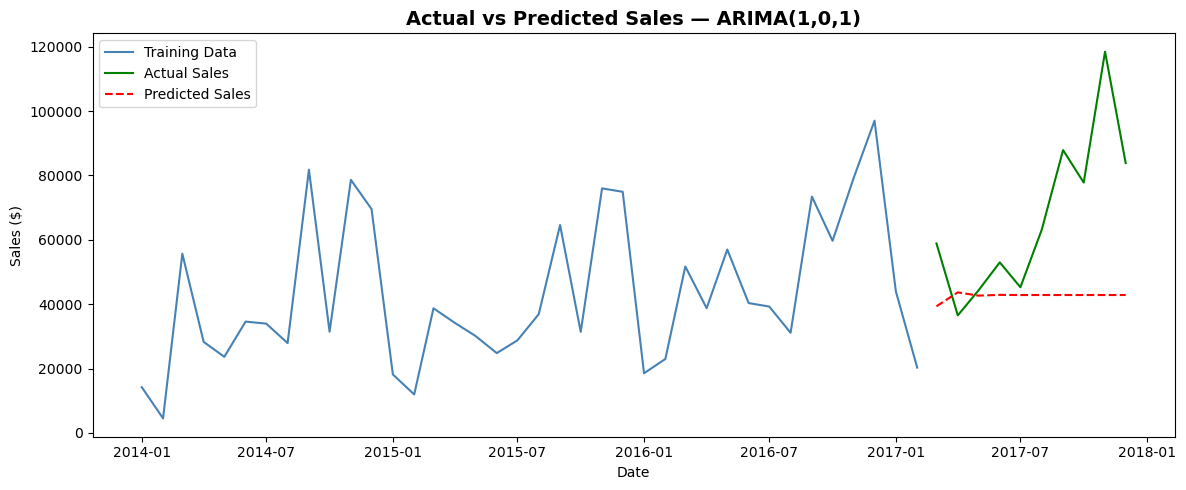

In [7]:
# Actual vs Predicted Plot
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, color='steelblue', label='Training Data')
plt.plot(test.index, test, color='green', label='Actual Sales')
plt.plot(predictions.index, predictions, color='red', 
         linestyle='--', label='Predicted Sales')
plt.title('Actual vs Predicted Sales — ARIMA(1,0,1)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Future Forecast
Forecasting sales for the next 3 months (Jan-Mar 2018).

In [8]:
# Retraining on full data for future forecast
final_model = ARIMA(monthly_sales, order=(1, 0, 1))
final_fitted = final_model.fit()

# Forecasting next 3 months
forecast = final_fitted.forecast(steps=3)
forecast_index = pd.date_range(start='2018-01-01', periods=3, freq='MS')
forecast.index = forecast_index

print("📅 3 Month Sales Forecast (2018):")
print("=" * 40)
for date, value in forecast.items():
    print(f"{date.strftime('%B %Y')} → ${value:,.0f}")

📅 3 Month Sales Forecast (2018):
January 2018 → $70,398
February 2018 → $63,344
March 2018 → $58,498
